## Assignment 2: $k$ Nearest Neighbor

### Do any four.

I did Q1, Q3, Q4, and Q5.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?

Regression provides a continuous / numeric output, while classification provides a discrete / categorical one. For example, a regression model for cars could predict car price based on color and mileage, while a classification model could predict type of car based on the same inputs.

2. What is a confusion table/matrix? What does it help us understand about a model's performance?

A confusion matrix lets us compare predictions with actual values. It helps us understand how often a model outputs false positives, false negatives, true positives, and true negatives.

3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifier's predictive performance?

Accuracy is the percentage of the time that a model's prediction matches the actual value; it is the proportion of cases that a model predicted correctly. This might not be entirely sufficient because a classifier can have systematic issues in its predictive performance that are not shown by just one number. Only using one number doesn't allow us to see other nuances in model performance.

4. What does the root mean squared error quantify about a particular model?

Root mean squared error tells us the distance from the actual values to the predicted ones, weighted by sample size. Squaring our error allows us to penalize big mistakes, taking the mean allows us to adjust for different sample sizes, and taking the square root allows us to be in units that align with our predictions.

5. What are overfitting and underfitting?

Overfitting happens when our model is too complex; variance is high and bias is low. An overfit model fits too much to noise and not enough to actual signal. Underfitting happens when our model is not complex enough; bias is high and variance is low. An underfit model fits too much to only signal and not enough to noise.

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?

A train-test split allows us to see how our model performs on unforseen data. After all, the point of creating models is to have predictions for future inputs. Choosing $k$ by evaluating accuracy or RMSE on the test set allows us to create a model that maximizes accuracy or minimizes RMSE and thus, ideally, performs better on new data.

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Reporting a class label as a prediction is simpler and allows for one definitive answer. This is more convenient but provides a less holistic picture. A probability distribution is thus more descriptive and gives us more info. It is more work to interpret, though.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.

In [2]:
CARS = pd.read_csv('../data/USA_cars_datasets.csv')
CARS = CARS[['price', 'year', 'mileage']]
CARS.head()

,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


In [3]:
CARS.shape

(2499, 3)

In [4]:
CARS.isna().sum()

price      0
year       0
mileage    0
dtype: int64

There are no `NA`s to handle.

2. Maxmin normalize `year` and `mileage`.

In [5]:
def maxmin(x):
    u = (x-min(x)) / (max(x)-min(x))
    return u

x = CARS[['year', 'mileage']]
x = x.apply(maxmin)

3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.

In [6]:
y = CARS['price']
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=343)

4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?

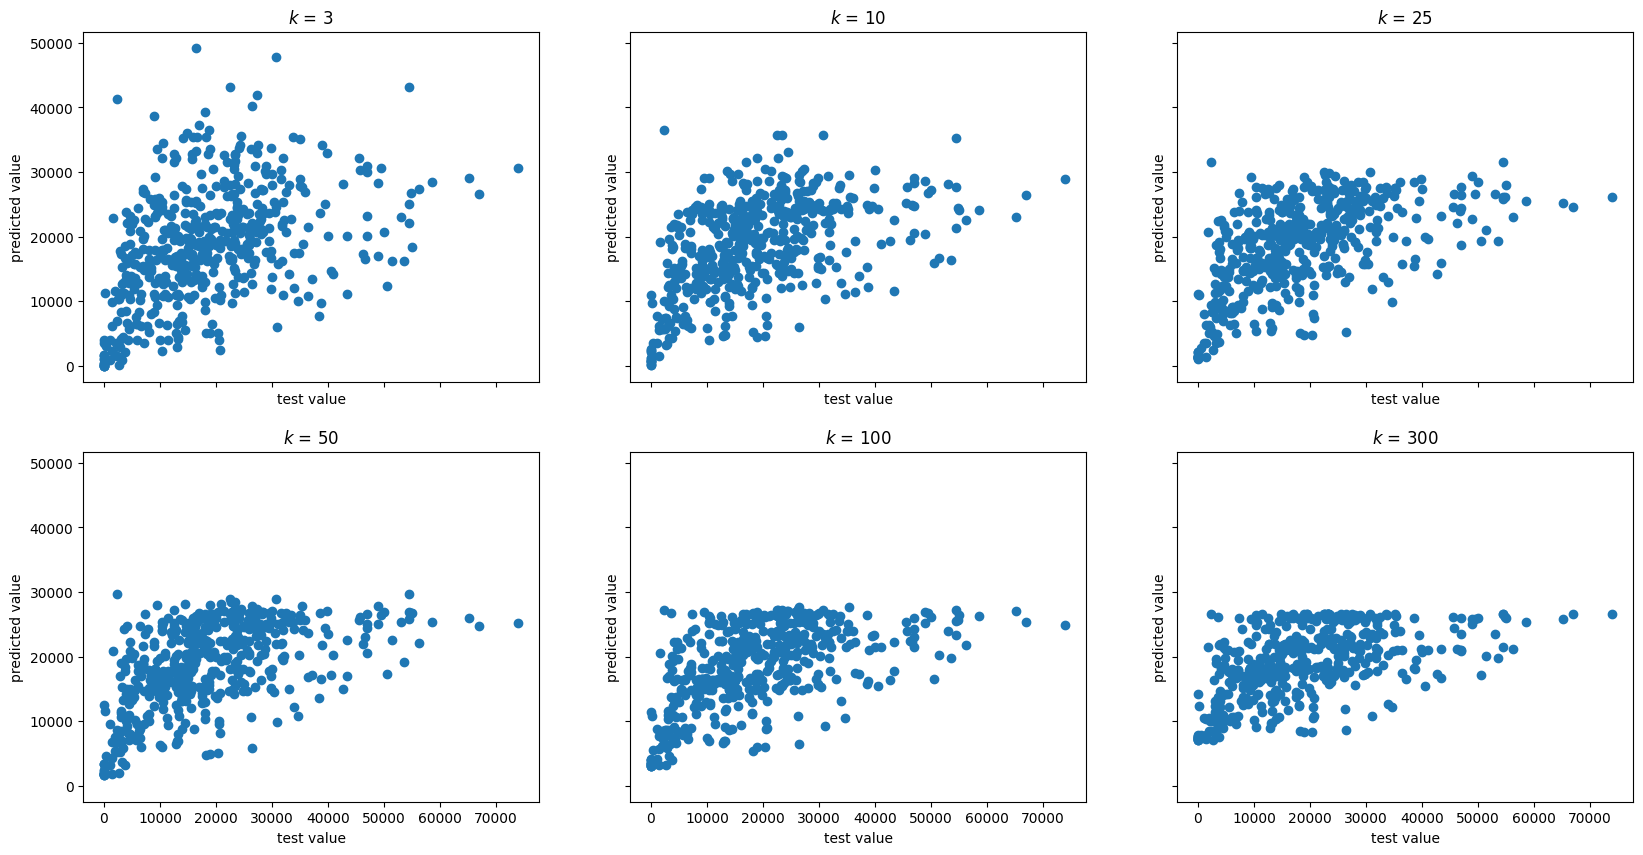

In [7]:
ks = [3, 10, 25, 50, 100, 300]
mses = []

def mse(ytest, yhat):
    mse = np.sum( (ytest - yhat) ** 2 ) / len(ytest)
    return mse

fig, axs = plt.subplots(2, 3, figsize=(20,10), sharex=True, sharey=True)
axIndex = 0
axIndexes = [(0,0), (0,1), (0,2), (1,0), (1,1), (1,2)]

for k in ks:
    model = KNeighborsRegressor(n_neighbors=k)
    model = model.fit(xtrain, ytrain)
    yhat = model.predict(xtest)

    thisax = axs[axIndexes[axIndex]]
    thisax.scatter(ytest, yhat)
    title = '$k$ = {k}'.format(k = k)
    thisax.set_title(title)
    thisax.set_xlabel('test value')
    thisax.set_ylabel('predicted value')
    axIndex = axIndex + 1

    mses.append(mse(ytest, yhat))

plt.show()

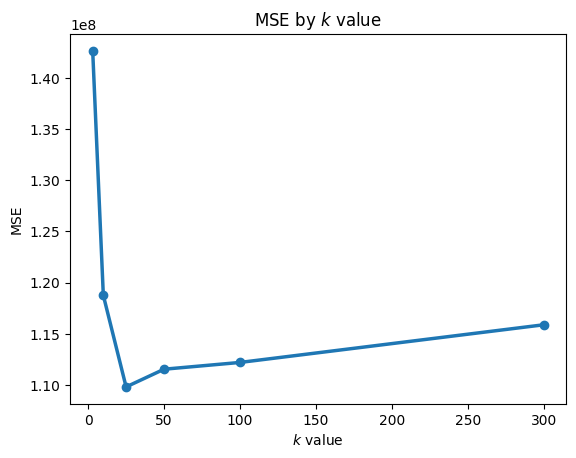

In [8]:
plt.plot(ks, mses, marker='o', linewidth=2.5)
plt.title('MSE by $k$ value')
plt.xlabel('$k$ value')
plt.ylabel('MSE')
plt.show()

As $k$ increases, the variance increases and the bias decreases. The points become more clustered together under ~30,000 dollars. Also as $k$ increases, the MSE first dramatically decreases and then gradually increases.

5. Determine the optimal $k$ for these data.

The optimal $k$ for this data (out of the $k$ values specified) is 10. That is point at which the MSE is minimized.

6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

With a small $k$ value like $3$, the model was underfitting. It was not complex enough and the points in the scatterplot were very spread out. As $k$ grew to values like $50$, $100$, and $300$, the model was overfiting. It was too complex and the points in the scatterplot were closer together but never predicting above ~30,000 dollars.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.

In [9]:
HEARTS = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')
HEARTS.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [10]:
HEARTS.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

There are no `NA`s to handle.

In [11]:
HEARTS = HEARTS.drop('time', axis=1)
HEARTS.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1


2. Make a correlation matrix. What variables are strongly associated with a death event?

In [12]:
HEARTS.corr()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
age,1.000000,0.088006,-0.081584,-0.101012,0.060098,0.093289,-0.052354,0.159187,-0.045966,0.065430,0.018668,0.253729
anaemia,0.088006,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.043786,0.052174,0.041882,-0.094769,-0.107290,0.066270
creatinine_phosphokinase,-0.081584,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.024463,-0.016408,0.059550,0.079791,0.002421,0.062728
diabetes,-0.101012,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,0.092193,-0.046975,-0.089551,-0.157730,-0.147173,-0.001943
ejection_fraction,0.060098,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.072177,-0.011302,0.175902,-0.148386,-0.067315,-0.268603
high_blood_pressure,0.093289,0.038182,-0.070590,-0.012732,0.024445,1.000000,0.049963,-0.004935,0.037109,-0.104615,-0.055711,0.079351
platelets,-0.052354,-0.043786,0.024463,0.092193,0.072177,0.049963,1.000000,-0.041198,0.062125,-0.125120,0.028234,-0.049139
serum_creatinine,0.159187,0.052174,-0.016408,-0.046975,-0.011302,-0.004935,-0.041198,1.000000,-0.189095,0.006970,-0.027414,0.294278
serum_sodium,-0.045966,0.041882,0.059550,-0.089551,0.175902,0.037109,0.062125,-0.189095,1.000000,-0.027566,0.004813,-0.195204
sex,0.065430,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.125120,0.006970,-0.027566,1.000000,0.445892,-0.004316


In [13]:
HEARTS.corr()['DEATH_EVENT'].sort_values(ascending=False)

DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
Name: DEATH_EVENT, dtype: float64

`serum_creatinine` and `age` are the most positively correlated with a death event.

3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?

In [14]:
vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

for var in vars:
    print(HEARTS.groupby(var)['DEATH_EVENT'].describe())
    print()
    print()

         count      mean       std  min  25%  50%  75%  max
anaemia                                                    
0        170.0  0.294118  0.456991  0.0  0.0  0.0  1.0  1.0
1        129.0  0.356589  0.480859  0.0  0.0  0.0  1.0  1.0


          count      mean       std  min  25%  50%  75%  max
diabetes                                                    
0         174.0  0.321839  0.468530  0.0  0.0  0.0  1.0  1.0
1         125.0  0.320000  0.468353  0.0  0.0  0.0  1.0  1.0


                     count      mean       std  min  25%  50%  75%  max
high_blood_pressure                                                    
0                    194.0  0.293814  0.456687  0.0  0.0  0.0  1.0  1.0
1                    105.0  0.371429  0.485504  0.0  0.0  0.0  1.0  1.0


     count      mean       std  min  25%  50%  75%  max
sex                                                    
0    105.0  0.323810  0.470173  0.0  0.0  0.0  1.0  1.0
1    194.0  0.319588  0.467523  0.0  0.0  0.0  1.0  1.

A larger proportion of the population dies when the `sex` variable is $1$ rather than $0$. For all the other variables, more of the population dies when the variable equals $0$ rather than $1$.

4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.

In [15]:
x = HEARTS[['serum_creatinine', 'age', 'sex']]
y = HEARTS['DEATH_EVENT']

5. Maxmin normalize all of the variables in `X`.

In [16]:
x = x.apply(maxmin)
x.head()

,serum_creatinine,age,sex
0,0.157303,0.636364,1.0
1,0.067416,0.272727,1.0
2,0.089888,0.454545,1.0
3,0.157303,0.181818,1.0
4,0.247191,0.454545,0.0


6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).

In [17]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=343)

7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.

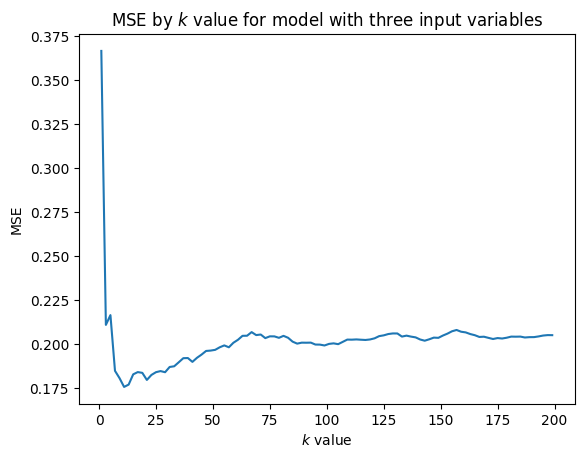

In [18]:
ks = [(2*k+1) for k in range(100)] # odd numbers from 1 to 201
mses = []

for k in ks:
    model = KNeighborsRegressor(n_neighbors=k)
    model = model.fit(xtrain, ytrain)
    yhat = model.predict(xtest)
    mses.append(mse(ytest, yhat))

sns.lineplot(x=ks, y=mses)
plt.title('MSE by $k$ value for model with three input variables')
plt.xlabel('$k$ value')
plt.ylabel('MSE')
plt.show()

In [19]:
index = np.argmin(mses)
bestk = ks[index]
bestMSE = np.max(mses)
print('best k is', bestk, 'with MSE of', bestMSE)

best k is 11 with MSE of 0.36666666666666664


The optimal $k$ in this situation is $11$ because it minimizes the MSE to ~$0.37$.

8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

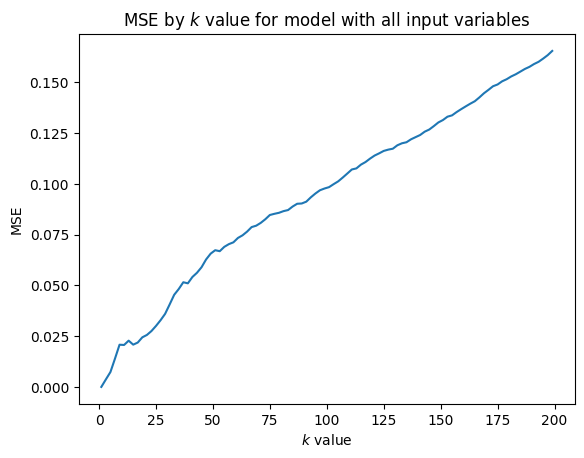

In [20]:
x2 = HEARTS
y2 = HEARTS['DEATH_EVENT']

# maxmin normalize
x2 = x2.apply(maxmin)

# train test split
x2train, x2test, y2train, y2test = train_test_split(x2, y2, test_size=0.2, random_state=343)

# make models and plot MSEs
mses2 = []

for k in ks:
    model = KNeighborsRegressor(n_neighbors=k)
    model = model.fit(x2train, y2train)
    yhat2 = model.predict(x2test)
    mses2.append(mse(y2test, yhat2))

sns.lineplot(x=ks, y=mses2)
plt.title('MSE by $k$ value for model with all input variables')
plt.xlabel('$k$ value')
plt.ylabel('MSE')
plt.show()

In [21]:
# find best k
mses2 = [1 if mse == 0 else mse for mse in mses2] # replace all 0s with 1
index2 = np.argmin(mses2)
bestk2 = ks[index2]
bestMSE2 = np.min(mses2)
print('best k is', bestk2, 'with MSE of', bestMSE2)

best k is 3 with MSE of 0.0037037037037037043


This model with all the variables has a lower MSE than the model with only three variables. In practice, if I had the resources for it, I would probably want to use the model with more variables since it has a lower MSE. However, it would require more computations, so if I wanted to maximize efficiency / speed, I could also use the model with only three input variables.

In [22]:
possibleVars = HEARTS.columns.tolist()
possibleVars.remove('DEATH_EVENT')
print(possibleVars)

['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']


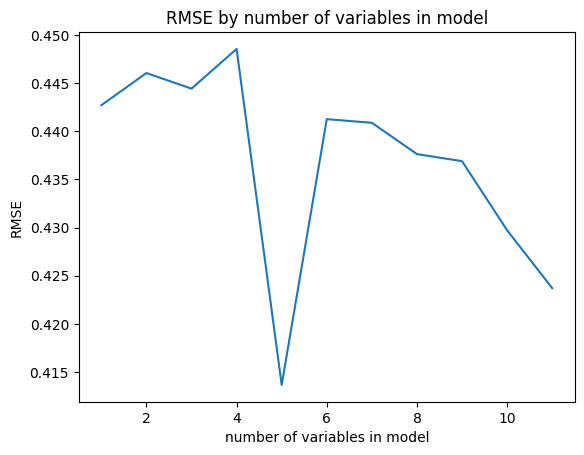

In [23]:
def rmse(ytest, yhat):
    return np.sqrt(mse(ytest, yhat))

numVars = [i + 1 for i in range(len(possibleVars))] # [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
bestrmses = []

# make various models
for i in numVars:
    
    # select variables
    vars = possibleVars[:i]
    x = HEARTS[vars]
    y = HEARTS['DEATH_EVENT']

    # maxmin normalize
    x = x.apply(maxmin)

    # train test split
    xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=343)

    # make models and find best k
    ks = [(2*k+1) for k in range(100)]
    rmses = []
    for k in ks:
        model = KNeighborsRegressor(n_neighbors=k)
        model = model.fit(xtrain, ytrain)
        yhat = model.predict(xtest)
        rmses.append(rmse(ytest, yhat))

    index = np.argmin(rmses)
    bestk = ks[index]
    bestRMSE = np.min(rmses)

    # record best rmse
    bestrmses.append(bestRMSE)

sns.lineplot(x=numVars, y=bestrmses)
plt.title('RMSE by number of variables in model')
plt.xlabel('number of variables in model')
plt.ylabel('RMSE')
plt.show()


No, more variables is not always better. This is shown in the above graph where a 7-variable model has a higher RMSE than a 5-variable model. Adding more variables can lead to an overfit model that is too complex. 

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?

In [24]:
ANIMALS = pd.read_csv('../data/zoo.csv')
ANIMALS.head()

,animal,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [25]:
for i in range(1, 8):
    print(f'class {i}:', ANIMALS[ANIMALS['class'] == i]['animal'].tolist())

class 1: ['aardvark', 'antelope', 'bear', 'boar', 'buffalo', 'calf', 'cavy', 'cheetah', 'deer', 'dolphin', 'elephant', 'fruitbat', 'giraffe', 'girl', 'goat', 'gorilla', 'hamster', 'hare', 'leopard', 'lion', 'lynx', 'mink', 'mole', 'mongoose', 'opossum', 'oryx', 'platypus', 'polecat', 'pony', 'porpoise', 'puma', 'pussycat', 'raccoon', 'reindeer', 'seal', 'sealion', 'squirrel', 'vampire', 'vole', 'wallaby', 'wolf']
class 2: ['chicken', 'crow', 'dove', 'duck', 'flamingo', 'gull', 'hawk', 'kiwi', 'lark', 'ostrich', 'parakeet', 'penguin', 'pheasant', 'rhea', 'skimmer', 'skua', 'sparrow', 'swan', 'vulture', 'wren']
class 3: ['pitviper', 'seasnake', 'slowworm', 'tortoise', 'tuatara']
class 4: ['bass', 'carp', 'catfish', 'chub', 'dogfish', 'haddock', 'herring', 'pike', 'piranha', 'seahorse', 'sole', 'stingray', 'tuna']
class 5: ['frog', 'frog', 'newt', 'toad']
class 6: ['flea', 'gnat', 'honeybee', 'housefly', 'ladybird', 'moth', 'termite', 'wasp']
class 7: ['clam', 'crab', 'crayfish', 'lobster

Here are my loose descriptions of each of the classes:
1. land animals, stuff that has four legs + dolphins and purpoises for some reason
2. birds
3. snakes / reptiles and turtles
4. fish / sea animals
5. amphibians
6. bugs
7. crustaceans + worm

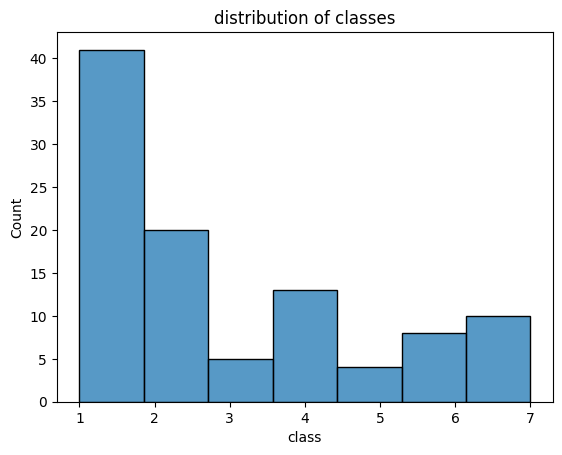

In [26]:
sns.histplot(ANIMALS['class'], bins=7)
plt.title('distribution of classes')
plt.show()

In [27]:
ANIMALS.columns

Index(['animal', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic',
       'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins',
       'legs', 'tail', 'domestic', 'catsize', 'class'],
      dtype='object')

In [28]:
uniqueVals = pd.DataFrame()

def getnunique(col, fil):
    return [fil[col].nunique()]

for classNum in range(1, 8):
    fil = ANIMALS[ANIMALS['class'] == classNum]
    newRow = pd.DataFrame({
        'class': [classNum],
        'animal': getnunique('animal', fil),
        'hair': getnunique('hair', fil),
        'feathers': getnunique('feathers', fil),
        'eggs': getnunique('eggs', fil),
        'milk': getnunique('milk', fil),
        'airborne': getnunique('airborne', fil),
        'aquatic': getnunique('aquatic', fil),
        'predator': getnunique('predator', fil),
        'toothed': getnunique('toothed', fil),
        'backbone': getnunique('backbone', fil),
        'breathes': getnunique('breathes', fil),
        'venomous': getnunique('venomous', fil),
        'fins': getnunique('fins', fil),
        'legs': getnunique('legs', fil),
        'tail': getnunique('tail', fil),
        'domestic': getnunique('domestic', fil),
        'catsize': getnunique('catsize', fil)
    })
    uniqueVals = pd.concat([uniqueVals, newRow], ignore_index=True)

newRow = pd.DataFrame({
    'class': ['all'],
    'animal': ANIMALS['animal'].nunique(),
    'hair': ANIMALS['hair'].nunique(),
    'feathers': ANIMALS['feathers'].nunique(),
    'eggs': ANIMALS['eggs'].nunique(),
    'milk': ANIMALS['milk'].nunique(),
    'airborne': ANIMALS['airborne'].nunique(),
    'aquatic': ANIMALS['aquatic'].nunique(),
    'predator': ANIMALS['predator'].nunique(),
    'toothed': ANIMALS['toothed'].nunique(),
    'backbone': ANIMALS['backbone'].nunique(),
    'breathes': ANIMALS['breathes'].nunique(),
    'venomous': ANIMALS['venomous'].nunique(),
    'fins': ANIMALS['fins'].nunique(),
    'legs': ANIMALS['legs'].nunique(),
    'tail': ANIMALS['tail'].nunique(),
    'domestic': ANIMALS['domestic'].nunique(),
    'catsize': ANIMALS['catsize'].nunique()
})

uniqueVals = pd.concat([uniqueVals, newRow], ignore_index=True)

uniqueVals

,class,animal,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1,41,2,1,2,1,2,2,2,2,1,1,1,2,3,2,2,2
1,2,20,1,1,1,1,2,2,2,1,1,1,1,1,1,1,2,2
2,3,5,1,1,2,1,1,2,2,2,1,2,2,1,2,1,1,2
3,4,13,1,1,1,1,1,1,2,1,1,1,2,1,1,1,2,2
4,5,3,1,1,1,1,1,1,2,1,1,1,2,1,1,2,1,1
5,6,8,2,1,1,1,2,1,2,1,1,1,2,1,1,1,2,1
6,7,10,1,1,2,1,1,2,2,1,1,2,2,1,5,2,1,2
7,all,100,2,2,2,2,2,2,2,2,2,2,2,2,6,2,2,2


In [29]:
def printUniqueVal(classNum, col):
    val = ANIMALS[ANIMALS['class'] == classNum][col].unique()
    print(f'all animals in class {classNum} have a \'{col}\' value of {val}')

cols = uniqueVals.columns.tolist()
cols.remove('class')
for col in cols:
    for classNum in range(1, 8):
        if uniqueVals[uniqueVals['class'] == classNum][col].item() == 1:
            printUniqueVal(classNum, col)

all animals in class 2 have a 'hair' value of [0]
all animals in class 3 have a 'hair' value of [0]
all animals in class 4 have a 'hair' value of [0]
all animals in class 5 have a 'hair' value of [0]
all animals in class 7 have a 'hair' value of [0]
all animals in class 1 have a 'feathers' value of [0]
all animals in class 2 have a 'feathers' value of [1]
all animals in class 3 have a 'feathers' value of [0]
all animals in class 4 have a 'feathers' value of [0]
all animals in class 5 have a 'feathers' value of [0]
all animals in class 6 have a 'feathers' value of [0]
all animals in class 7 have a 'feathers' value of [0]
all animals in class 2 have a 'eggs' value of [1]
all animals in class 4 have a 'eggs' value of [1]
all animals in class 5 have a 'eggs' value of [1]
all animals in class 6 have a 'eggs' value of [1]
all animals in class 1 have a 'milk' value of [1]
all animals in class 2 have a 'milk' value of [0]
all animals in class 3 have a 'milk' value of [0]
all animals in class 4

In [30]:
for classNum in range(1, 8):
    vars = []
    for col in cols:
        if uniqueVals[uniqueVals['class'] == classNum][col].item() == 1:
            vars.append(col)
    print(f'likely predictors for class {classNum}:', vars)

likely predictors for class 1: ['feathers', 'milk', 'backbone', 'breathes', 'venomous']
likely predictors for class 2: ['hair', 'feathers', 'eggs', 'milk', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail']
likely predictors for class 3: ['hair', 'feathers', 'milk', 'airborne', 'backbone', 'fins', 'tail', 'domestic']
likely predictors for class 4: ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'toothed', 'backbone', 'breathes', 'fins', 'legs', 'tail']
likely predictors for class 5: ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'toothed', 'backbone', 'breathes', 'fins', 'legs', 'domestic', 'catsize']
likely predictors for class 6: ['feathers', 'eggs', 'milk', 'aquatic', 'toothed', 'backbone', 'breathes', 'fins', 'legs', 'tail', 'catsize']
likely predictors for class 7: ['hair', 'feathers', 'milk', 'airborne', 'toothed', 'backbone', 'fins', 'domestic']


2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

In [31]:
vars = cols
vars.remove('animal')
x = ANIMALS[vars]
y = ANIMALS['class']
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.5, random_state=343)

3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.

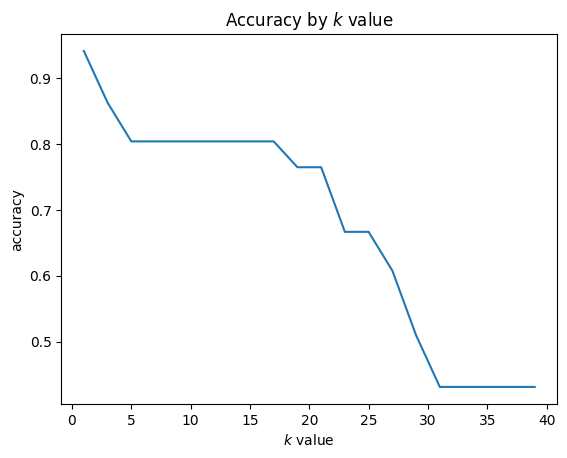

In [32]:
ks = [(2*k+1) for k in range(20)] 
accuracies = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model = model.fit(xtrain, ytrain)
    yhat = model.predict(xtest)
    accuracies.append(accuracy_score(ytest, yhat))

sns.lineplot(x=ks, y=accuracies)
plt.title('Accuracy by $k$ value')
plt.xlabel('$k$ value')
plt.ylabel('accuracy')
plt.show()

In [33]:
index = np.argmax(accuracies)
bestk = ks[index]
bestAccuracy = np.max(accuracies)
print('best k is', bestk, 'with accuracy of', bestAccuracy)

best k is 1 with accuracy of 0.9411764705882353


In [34]:
# the best k should not be 1, so we try a different strategy
kframe = pd.DataFrame({'k': ks, 'accuracy': accuracies})
kframe.sort_values('accuracy', ascending=False)

,k,accuracy
0,1,0.941176
1,3,0.862745
2,5,0.803922
3,7,0.803922
4,9,0.803922
5,11,0.803922
6,13,0.803922
7,15,0.803922
8,17,0.803922
9,19,0.764706


I chose $3$ as the best $k$ value for my model because it maximized the accuracy. I made various models with different $k$ values and found $3$ to be the best number. I also excluded $k=1$ because that wouldn't really create a real model; it would be more of just a lookup.

In [35]:
bestModel = KNeighborsClassifier(n_neighbors=3)
bestModel = bestModel.fit(xtrain, ytrain)
yhat = bestModel.predict(xtest)

4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?

In [36]:
pd.DataFrame(confusion_matrix(ytest, yhat))

,0,1,2,3,4,5,6
0,22,0,0,0,0,0,0
1,0,12,0,0,0,0,0
2,0,0,0,2,2,0,0
3,0,0,0,5,0,0,0
4,0,0,0,0,0,0,0
5,0,0,0,0,0,2,0
6,0,0,0,0,1,2,3


The model with $k=3$ has an accuracy of about 86%. It seems to make mistakes when predicting animals in class 2 mistaking them for animals in classes 3 and 4 — ie. it mistakes birds for reptiles and fish. This sort of makes sense because classes 2, 3, and 4 are all characterized by a `hair` value of 0, a `milk` value of 0, a `backbone` value of 1, and a `tail` value of 1. Class 4 was also never predicted correctly. When class 4 was predicted, it was for the actual classes 2 and 6 (mistaking 6 for 4 means mistaking fish for crustaceans which makes sense). Class 6 also had mistakes associated with it; the model predicted 4 and 5 instead of 6. That is, the model mislabeled crustaceanas as fish and amphibians; this makes sense. 


5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

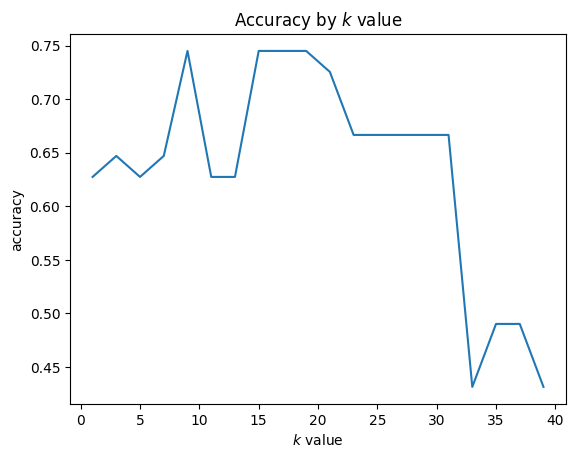

In [37]:
# select variables
x2 = ANIMALS[['milk', 'aquatic', 'airborne']]
y2 = ANIMALS['class']

# train test split
xtrain2, xtest2, ytrain2, ytest2 = train_test_split(x2, y2, test_size=0.5, random_state=343)

# find best k
ks2 = [(2*k+1) for k in range(20)] 
accuracies2 = []

for k in ks2:
    model = KNeighborsClassifier(n_neighbors=k)
    model = model.fit(xtrain2, ytrain2)
    yhat2 = model.predict(xtest2)
    accuracies2.append(accuracy_score(ytest2, yhat2))

sns.lineplot(x=ks2, y=accuracies2)
plt.title('Accuracy by $k$ value')
plt.xlabel('$k$ value')
plt.ylabel('accuracy')
plt.show()

In [38]:
kframe2 = pd.DataFrame({'k': ks2, 'accuracy': accuracies2})
kframe2.sort_values('accuracy', ascending=False)

,k,accuracy
8,17,0.745098
9,19,0.745098
7,15,0.745098
4,9,0.745098
10,21,0.725490
15,31,0.666667
13,27,0.666667
12,25,0.666667
14,29,0.666667
11,23,0.666667


I chose the $17$ as the best $k$ since it maximized accuracy.

In [39]:
# make best model
bestModel2 = KNeighborsClassifier(n_neighbors=17)
bestModel2 = bestModel2.fit(xtrain2, ytrain2)
yhat2 = bestModel2.predict(xtest2)

# make confusion matrix
pd.DataFrame(confusion_matrix(ytest2, yhat2))

,0,1,2,3,4,5
0,22,0,0,0,0,0
1,0,11,0,1,0,0
2,0,3,0,1,0,0
3,0,0,0,5,0,0
4,0,2,0,0,0,0
5,0,2,0,4,0,0


Classes 2, 4, and 5 are never predicted.

In [40]:
import warnings
warnings.filterwarnings('ignore')

yprobs = bestModel2.predict_proba(xtest2.values)
yprobs

array([[0.17647059, 0.23529412, 0.05882353, 0.11764706, 0.11764706,
        0.17647059, 0.11764706],
       [0.05882353, 0.05882353, 0.        , 0.47058824, 0.23529412,
        0.        , 0.17647059],
       [0.88235294, 0.        , 0.        , 0.        , 0.        ,
        0.05882353, 0.05882353],
       [0.05882353, 0.41176471, 0.05882353, 0.        , 0.        ,
        0.35294118, 0.11764706],
       [0.05882353, 0.05882353, 0.        , 0.47058824, 0.23529412,
        0.        , 0.17647059],
       [0.88235294, 0.        , 0.        , 0.        , 0.        ,
        0.05882353, 0.05882353],
       [0.05882353, 0.41176471, 0.05882353, 0.        , 0.        ,
        0.35294118, 0.11764706],
       [0.88235294, 0.        , 0.        , 0.        , 0.        ,
        0.05882353, 0.05882353],
       [0.64705882, 0.        , 0.        , 0.17647059, 0.17647059,
        0.        , 0.        ],
       [0.05882353, 0.05882353, 0.        , 0.47058824, 0.23529412,
        0.        , 0.1

In [41]:
class2probs = []
class4probs = []
class5probs = []
for probArray in yprobs:
    class2probs.append(probArray[1]) # 0-based indexing means that the probability for class 2 is at index 1
    class4probs.append(probArray[3])
    class5probs.append(probArray[4])

print('class 2 prob min:', np.min(class2probs))
print('class 2 prob max:', np.max(class2probs))
print('class 4 prob min:', np.min(class4probs))
print('class 4 prob max:', np.max(class4probs))
print('class 5 prob min:', np.min(class5probs))
print('class 6 prob max:', np.max(class5probs))

class 2 prob min: 0.0
class 2 prob max: 0.4117647058823529
class 4 prob min: 0.0
class 4 prob max: 0.47058823529411764
class 5 prob min: 0.0
class 6 prob max: 0.23529411764705882


Yes. All of the classes are represented in the probabilities at some point. However, the probabilities for classes 2, 4, and 5 are always low. Class 2 never gets a probability over ~4.1%, class 4 never gets a probability over ~4.7%, and class 5 never gets a probability over ~2.4%.